In [30]:
# Code
# 1. Import Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score 




In [31]:
# 2. Load Dataset
data = pd.read_csv ("student.csv")
df = pd.DataFrame(data)
print("_____________________________\n")
print("First Few Rows of Data set")
print("____________________________\n")
print(df.head())
print("_____________________________\n")
print("Data set Information")
print("_____________________________\n")
print(df.info())
print("_____________________________\n")
print("Statistical summary")
print("_____________________________\n")
print(df.describe())
print("_____________________________\n")
print("Null values")
print("_____________________________\n")
print(df.isnull().sum())


_____________________________

First Few Rows of Data set
____________________________

   study_hours  attendance  sleep_hours  internet_usage  \
0            7          56            8               7   
1            4          69            5               3   
2           11          60            7               6   
3            8          99            9               8   
4            5          52            8               6   

   assignments_completed  previous_score  exam_score placement_status  
0                     10              62      100.00           Placed  
1                      8              56      100.00           Placed  
2                     10              45      100.00           Placed  
3                      4              55       90.17           Placed  
4                      8              40       78.82           Placed  
_____________________________

Data set Information
_____________________________

<class 'pandas.core.frame.DataFrame'>
Rang

In [32]:
# 3. Feature Selection
X = data[['study_hours', 'attendance', 'sleep_hours', 'previous_score']]
y = data['exam_score']


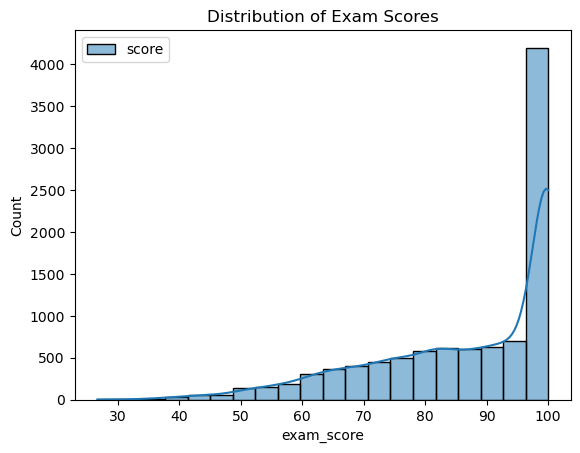

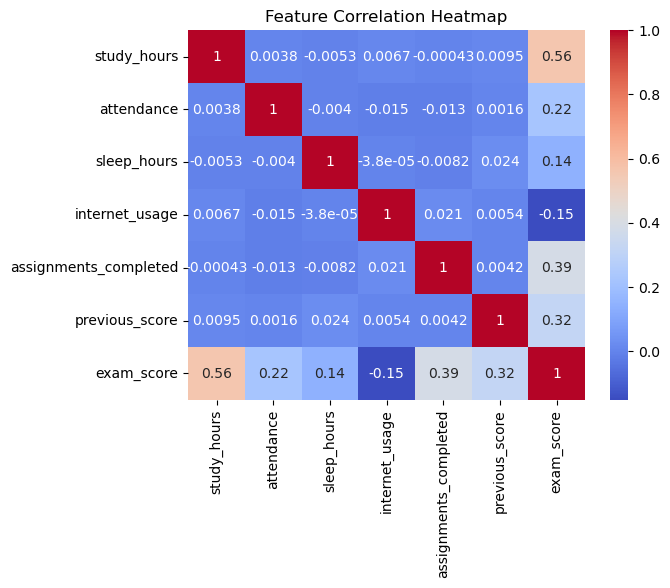

In [33]:
# 4. EDA

# Univariate Analysis 
sns.histplot(data['exam_score'], label = "score",bins=20, kde=True)
plt.title("Distribution of Exam Scores")
plt.legend()
plt.show()

# Bivariate Analysis : 
# Correlation : Heatmap
corr = df.select_dtypes(include = "number").corr()
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()








In [38]:
# 5. Train_test_split 
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

# 6. Linear Regression
l = LinearRegression()
l.fit(X_train,y_train)

# 7. Predict
y_pred = l.predict(X_test)

# 8. Evaluation metrics
print("_____________________________\n")
print("\n Model Evaluation")
print("_____________________________\n")

print("Intercept:",l.intercept_)
print("Coefficient:",l.coef_)
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))




_____________________________


 Model Evaluation
_____________________________

Intercept: 31.643958916272275
Coefficient: [2.6519303  0.19654262 1.25323179 0.26740265]
Mean Squared Error: 119.41253261516432
R2 Score: 0.4802255175919401


In [37]:
# 9.Predict new _student
new_student = pd.DataFrame({
    'study_hours': [5],
    'attendance': [90],
    'sleep_hours': [7],
    'previous_score': [70]
})

# Predict exam score
predicted_score = l.predict(new_student)
print("Predicted Exam Score:", predicted_score[0])


Predicted Exam Score: 90.08325458109768
